# Habitat 3.0 Benchmarking

In [19]:
%%bash
# Symlinks from notebooks 08/09
mkdir -p /content/data/objects /content/data/robots

ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets /content/data/hab3_bench_assets
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/ycb /content/data/objects/ycb
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm /content/data/robots/hab_spot_arm

ln -sfn /content/data /content/habitat-lab-v033/data 2>/dev/null || true

cat > /tmp/nvidia_egl.json << 'EOF'
{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}
EOF

# Restore clean YAMLs from GitHub, then patch them.
# Adds measure dependencies required by move_obj_reward / rearrange_cooperate_reward
# (must come BEFORE the reward measure in the list).
CFG_DIR=/content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench
BASE=https://raw.githubusercontent.com/facebookresearch/habitat-lab/v0.3.3/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench

for f in single_agent_bench.yaml multi_agent_bench.yaml; do
  curl -fsSL "$BASE/$f" -o "$CFG_DIR/$f"
done

python3 - <<'PY'
import re, os
deps = [
    "articulated_agent_force",
    "force_terminate",
    "object_to_goal_distance",
    "end_effector_to_object_distance",
]
cfg_dir = "/content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench"
for fname in ["single_agent_bench.yaml", "multi_agent_bench.yaml"]:
    p = os.path.join(cfg_dir, fname)
    s = open(p).read()
    target = "move_objects_reward" if "move_objects_reward" in s else "rearrange_cooperate_reward"
    m = re.search(r"(\n)(\s+)- " + target, s)
    if not m:
        print(f"{fname}: no anchor found, skipping"); continue
    indent = m.group(2)
    insertion = "".join(f"\n{indent}- {d}" for d in deps)
    s = s.replace(f"\n{indent}- {target}", f"{insertion}\n{indent}- {target}", 1)
    open(p, "w").write(s)
    print(f"patched {fname}: inserted deps before {target}")
PY
echo "Ready"

patched single_agent_bench.yaml: inserted deps before move_objects_reward
patched multi_agent_bench.yaml: inserted deps before rearrange_cooperate_reward
Ready


## 2. Inspect the official benchmark configs


In [20]:
%%bash
ls /content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench/

humanoid_oracle.yaml
multi_agent_bench.yaml
single_agent_bench.yaml
spot_humanoid_oracle.yaml
spot_oracle.yaml
spot_spot_oracle.yaml


In [21]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
pip install psutil
python -c "import psutil; print('psutil', psutil.__version__)"


psutil 7.2.2


In [22]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
if [ -d data/replica_cad ] && [ "$(ls -A data/replica_cad 2>/dev/null)" ]; then
  echo "replica_cad already present, skipping download"
else
  python -m habitat_sim.utils.datasets_download --uids replica_cad_dataset --data-path data/ --no-replace --no-prune
fi
ls data/replica_cad/ | head

replica_cad already present, skipping download
configs
LICENSE.txt
navmeshes
navmeshes_default
objects
README.md
replicaCAD.scene_dataset_config.json
stages
urdf


## 3. Benchmark 1: Single Spot robot with oracle nav


In [23]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

mkdir -p data/profile

for i in 1 2 3; do
  echo "=== robot_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robot_oracle_$i" \
      habitat.task.task_spec=tidy_house_2obj \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robot_oracle_[0-9]"

=== robot_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_1.txt
Ran 1 trial(s) with average FPS of 260.9027439498507 from [260.9027439498507].
=== robot_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_2.txt
Ran 1 trial(s) with average FPS of 210.96882769768982 from [210.96882769768982].
=== robot_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_3.txt
Ran 1 trial(s) with average FPS of 261.03869241597056 from [261.03869241597056].
1_300_-1_robot_oracle_1.txt
1_300_-1_robot_oracle_2.txt
1_300_-1_robot_oracle_3.txt


## 4. Benchmark 2: Single Humanoid with oracle nav


In [24]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== human_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/humanoid_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "human_oracle_$i" \
      habitat.task.task_spec=tidy_house_2obj \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_human_oracle_[0-9]"

=== human_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_1.txt
Ran 1 trial(s) with average FPS of 168.0152607013458 from [168.0152607013458].
=== human_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_2.txt
Ran 1 trial(s) with average FPS of 196.23430897540803 from [196.23430897540803].
=== human_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_3.txt
Ran 1 trial(s) with average FPS of 164.2473883903313 from [164.2473883903313].
1_300_-1_human_oracle_1.txt
1_300_-1_human_oracle_2.txt
1_300_-1_human_oracle_3.txt


## 5. Benchmark 3: Multi-agent Spot + Spot


In [25]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== robots_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_spot_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robots_oracle_$i" \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robots_oracle_[0-9]"

=== robots_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_1.txt
Ran 1 trial(s) with average FPS of 145.43834659062037 from [145.43834659062037].
=== robots_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_2.txt
Ran 1 trial(s) with average FPS of 145.6444490743568 from [145.6444490743568].
=== robots_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_3.txt
Ran 1 trial(s) with average FPS of 146.34932391767992 from [146.34932391767992].
1_300_-1_robots_oracle_1.txt
1_300_-1_robots_oracle_2.txt
1_300_-1_robots_oracle_3.txt


## 6. Benchmark 4: Multi-agent Spot + Humanoid


In [26]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== robot_human_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_humanoid_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robot_human_oracle_$i" \
      habitat.task.end_on_success=False \
      habitat.task.measurements.rearrange_cooperate_reward.end_on_collide=False \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robot_human_oracle_[0-9]"

=== robot_human_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_1.txt
Ran 1 trial(s) with average FPS of 134.03118616815019 from [134.03118616815019].
=== robot_human_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_2.txt
Ran 1 trial(s) with average FPS of 94.49812860248683 from [94.49812860248683].
=== robot_human_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_3.txt
Ran 1 trial(s) with average FPS of 134.01994783091965 from [134.01994783091965].
1_300_-1_robot_human_oracle_1.txt
1_300_-1_robot_human_oracle_2.txt
1_300_-1_robot_human_oracle_3.txt


## 7. Benchmark 5: Humanoid oracle, no skinning (ablation)
Same as b2 but swaps in the no-skinning humanoid URDF to measure skinning cost.
(`humanoid_pick_action` isn't loaded in v0.3.3, so removing it isn't possible/needed.)

In [27]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

# humanoid_oracle.yaml uses main_agent (not agent_1) and doesn't load humanoid_pick_action,
# so the only ablation here is swapping in the no-skinning URDF.
for i in 1 2 3; do
  echo "=== human_oracle_noskin trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/humanoid_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "human_oracle_noskin_$i" \
      habitat.simulator.agents.main_agent.articulated_agent_urdf='data/hab3_bench_assets/humanoids/female_0/female_0_no_skinning.urdf' \
      habitat.task.task_spec=tidy_house_2obj \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_human_oracle_noskin_[0-9]"

=== human_oracle_noskin trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_noskin_1.txt
Ran 1 trial(s) with average FPS of 145.20753062781057 from [145.20753062781057].
=== human_oracle_noskin trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_noskin_2.txt
Ran 1 trial(s) with average FPS of 193.37335143145938 from [193.37335143145938].
=== human_oracle_noskin trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_noskin_3.txt
Ran 1 trial(s) with average FPS of 129.43872873066317 from [129.43872873066317].
1_300_-1_human_oracle_noskin_1.txt
1_300_-1_human_oracle_noskin_2.txt
1_300_-1_human_oracle_noskin_3.txt


## 8. Plot results with h3_plot_bench.py
Patches the official script to skip variants we didn't run (the 9 dataset combos and `n_procs=16`), then runs it. Output: `data/profile/opts_1.pdf`.

In [28]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
unset MPLBACKEND
export MPLBACKEND=Agg

# Re-fetch clean script then patch:
#   - skip the 9 dataset variants
#   - only n_procs=1 (we didn't run 16)
#   - add human_oracle_noskin (b5) to the plotted variants
curl -fsSL "https://raw.githubusercontent.com/facebookresearch/habitat-lab/v0.3.3/scripts/hab3_bench/h3_plot_bench.py" \
  -o scripts/hab3_bench/h3_plot_bench.py

python3 - <<'PY'
import re
p = "scripts/hab3_bench/h3_plot_bench.py"
s = open(p).read()
s = s.replace("if True:", "if False:")
s = re.sub(r"for i in \[1, 16\]:", "for i in [1]:", s)
# Insert b5 into name_list right after "human_oracle"
s = s.replace(
    '("human_oracle", "[Human Oracle]"),',
    '("human_oracle", "[Human Oracle]"),\n    ("human_oracle_noskin", "[Human Oracle No Skin]"),',
)
open(p, "w").write(s)
print("patched")
PY

python scripts/hab3_bench/h3_plot_bench.py
ls -lh data/profile/opts_*.pdf

patched
[('robot_human_oracle', '[Robot-Human Oracle Paths]'), ('robots_oracle', '[Robots Oracle]'), ('human_oracle', '[Human Oracle]'), ('human_oracle_noskin', '[Human Oracle No Skin]'), ('robot_oracle', '[Robot Oracle]')]
data/profile/hab3/1_300_-1_robot_human_oracle_1.txt
data/profile/hab3/1_300_-1_robot_human_oracle_2.txt
data/profile/hab3/1_300_-1_robot_human_oracle_3.txt
data/profile/hab3/1_300_-1_robot_human_oracle_4.txt
data/profile/hab3/1_300_-1_robots_oracle_1.txt
data/profile/hab3/1_300_-1_robots_oracle_2.txt
data/profile/hab3/1_300_-1_robots_oracle_3.txt
data/profile/hab3/1_300_-1_robots_oracle_4.txt
data/profile/hab3/1_300_-1_human_oracle_1.txt
data/profile/hab3/1_300_-1_human_oracle_2.txt
data/profile/hab3/1_300_-1_human_oracle_3.txt
data/profile/hab3/1_300_-1_human_oracle_4.txt
data/profile/hab3/1_300_-1_human_oracle_noskin_1.txt
data/profile/hab3/1_300_-1_human_oracle_noskin_2.txt
data/profile/hab3/1_300_-1_human_oracle_noskin_3.txt
data/profile/hab3/1_300_-1_human_orac

## 9. View the plot inline
Convert PDF → PNG via poppler so it renders in the notebook output.

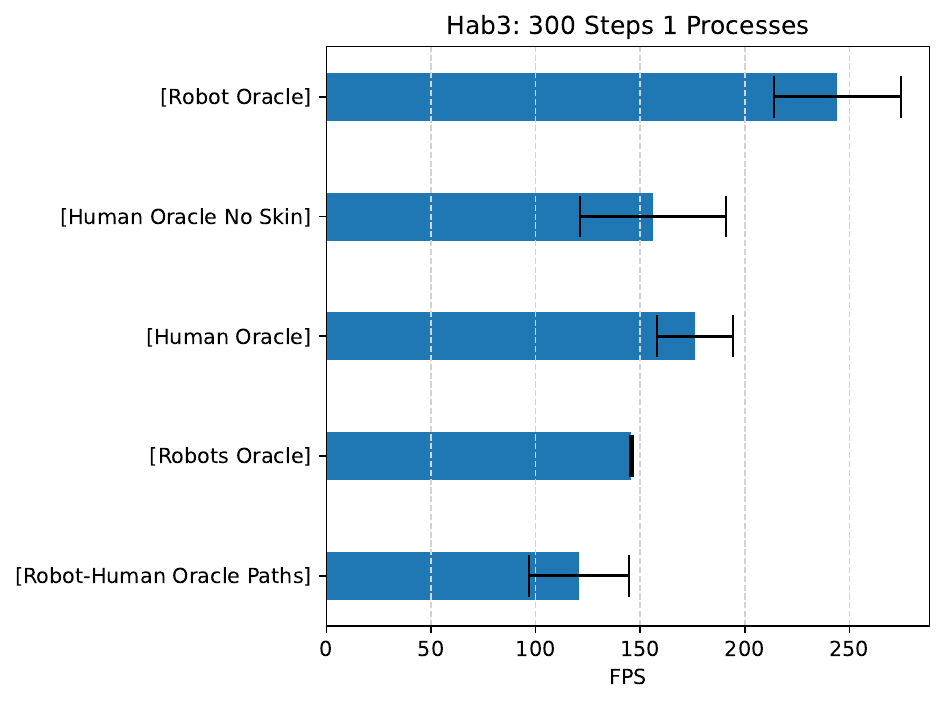

In [29]:
import subprocess, os
from PIL import Image
from IPython.display import display

pdf = "/content/habitat-lab-v033/data/profile/opts_1.pdf"
png_prefix = "/content/habitat-lab-v033/data/profile/opts_1"
png = png_prefix + "-1.png"

# Install poppler if pdftoppm isn't on PATH
if subprocess.call(["which", "pdftoppm"], stdout=subprocess.DEVNULL) != 0:
    subprocess.run(["apt-get", "install", "-y", "-q", "poppler-utils"], check=True)

subprocess.run(["pdftoppm", "-png", "-r", "150", pdf, png_prefix], check=True)
display(Image.open(png))